# PET monocellulare per ⁶⁴Cu: parametrizzazione e localizzazione del punto di decadimento

Il notebook simula, evento per evento, la catena
**decadimento β⁺ → range del positrone → annichilazione (2γ, acollinearità) → attenuazione nel mezzo → rivelazione in un anello LYSO → coincidenze (vere + casuali) → ricostruzione**,
e stima con quale precisione si ricostruisce la posizione della sorgente, cioè del nucleo cellulare marcato con ⁶⁴Cu.

**Premessa fisica.** Un singolo evento fornisce solo una *linea di risposta* (LOR, definito come la linea dritta immaginaria che connette 2 detector che simultaneamente registrano un paio di gamma). Il range del positrone (≈0.5 mm in media) e una TOF con risoluzione centimetrica rendono impossibile ricostruire il punto di decadimento *del singolo evento* con precisione cellulare (~µm). Il modo per arrivare alla scala cellulare è un altro: tutti i decadimenti provengono dallo stesso nucleo (R = 4 µm). La posizione della sorgente diventa quindi un parametro comune a N LOR e si stima come il punto più vicino a tutte, con errore ∝ s/√N. È l'approccio dei metodi di *single-cell PET tracking* (es. Jung et al., *Nat. Biomed. Eng.* 2020).

**Interpretazione dei parametri richiesti**
- *Rate di "ricombinazione" dei γ*: è l'efficienza con cui i due fotoni della stessa annichilazione, una volta rivelati singolarmente, vengono **riaccoppiati** in una coincidenza valida (perdite per tempo morto, pile-up, coincidenze multiple). Scelta: **ε_pair = 0.95**. Il rate risultante di coincidenze vere e casuali è calcolato più sotto.
- *Efficienza di ricostruzione*: frazione di coincidenze accoppiate che superano il preprocessing (clustering, cut di qualità) ed entrano nello stimatore. Scelta: **ε_rec = 0.90**. Lo stimatore robusto scarta poi da sé le LOR anomale (casuali).

Se hai l'output Geant4-DNA dei punti emissione/annichilazione, puoi caricarlo nella sezione 2 al posto del modello parametrico del range.

TOF di una PET odierna:
$$ \Delta x = \frac{c \cdot \Delta t}{2}$$
con tipicamente $c \approx 30 cm/ns$ e $\Delta t \sim 200 - 300 ps$ , ergo si ottiene un'incertezza spaziale dell'ordine dai 3 ai 6 cm per ogni LOR.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from pathlib import Path

rng = np.random.default_rng(64)

# palette (slot categoriali fissi + inchiostri neutri)
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d9d8d4"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 10,
})

## 1. Parametri

Tutte le lunghezze sono in **mm**, salvo dove indicato in µm.

| Blocco | Parametro | Valore | Motivazione |
|---|---|---|---|
| Sorgente | attività per cellula | 50 Bq | ordine di grandezza dell'uptake nel single-cell tracking (10–100 Bq/cellula) |
| | BR β⁺ ⁶⁴Cu | 0.1752 | NNDC; T½ = 12.701 h |
| | sorgente | sfera uniforme R = 4 µm | nucleo |
| | frazione non-2γ | 0.005 | o-Ps → 3γ in acqua |
| Range e⁺ | modello | Γ(k=2, θ=268 µm), troncata a 2.4 mm | riproduce la tua simulazione: media 536, mediana 450, p95 ≈1270 µm |
| Acollinearità | FWHM | 0.50° | annichilazione a riposo in acqua |
| Mezzo | goccia d'acqua | R = 5 mm, μ = 0.096 cm⁻¹ | contiene tutto il range; attenuazione ≲5% |
| Rivelatore | anello LYSO | R_in = 20 mm, spessore 10 mm, lunghezza assiale 20 mm | anello compatto attorno al pozzetto/chip |
| | pitch cristalli | 1.0 mm (trans-assiale e assiale) | stato dell'arte preclinico |
| | DOI | σ = 2 mm FWHM | lettura a doppia estremità |
| | μ(LYSO, 511 keV) | 0.87 cm⁻¹ | |
| | risoluzione energetica / finestra | 12% FWHM / 400–650 keV → frazione in finestra 0.70 | |
| | CTR / finestra di coincidenza | 200 ps FWHM / 2 ns | la TOF dà σ ≈ 13 mm lungo la LOR → **non usata** |
| Coincidenze | **ε_pair** ("ricombinazione") | **0.95** | scelta |
| | fondo intrinseco ¹⁷⁶Lu | 277 Bq/cm³ (39 Bq/g × 7.1 g/cm³), 30% in finestra | principale sorgente di singoli → casuali |
| Ricostruzione | **ε_rec** | **0.90** | scelta |

In [2]:
@dataclass(frozen=True)
class Params:
    # sorgente
    A_Bq: float = 50.0
    BR_beta_plus: float = 0.1752
    T_half_s: float = 12.701 * 3600
    R_nucleus_mm: float = 4e-3
    f_non2gamma: float = 0.005
    cell_pos: tuple = (0.60, -0.30, 0.80)       # posizione vera del nucleo [mm]
    # range positrone (Gamma), in mm
    range_k: float = 2.0
    range_theta: float = 0.268
    range_max: float = 2.4
    # acollinearita'
    acol_fwhm_deg: float = 0.50
    # mezzo
    R_medium: float = 5.0
    mu_water: float = 0.0096                    # 1/mm
    # rivelatore
    R_in: float = 20.0
    thick: float = 10.0
    L_ax: float = 20.0
    pitch: float = 1.0
    doi_fwhm: float = 2.0
    mu_lyso: float = 0.087                      # 1/mm
    f_window: float = 0.70
    ctr_ps: float = 200.0
    W_ns: float = 2.0
    # coincidenze / ricostruzione
    eps_pair: float = 0.95
    eps_rec: float = 0.90
    lu_Bq_cm3: float = 277.0
    lu_f_window: float = 0.30
    min_dphi_deg: float = 90.0                  # accettanza a "ventaglio" opposto
    # interruttori per il budget degli errori
    use_range: bool = True
    use_acol: bool = True
    use_detector: bool = True
    use_randoms: bool = True

P = Params()
R_out = P.R_in + P.thick
sigma_tof_mm = 299.792458e-3 * P.ctr_ps / 2 / 2.355
print(f"Raggio esterno anello: {R_out} mm, cristalli per anello: {round(2*np.pi*P.R_in/P.pitch)}, anelli assiali: {int(P.L_ax/P.pitch)}")
print(f"Risoluzione TOF lungo la LOR: sigma = {sigma_tof_mm:.1f} mm  (>> range e+ ~0.5 mm -> TOF inutile qui)")

Raggio esterno anello: 30.0 mm, cristalli per anello: 126, anelli assiali: 20
Risoluzione TOF lungo la LOR: sigma = 12.7 mm  (>> range e+ ~0.5 mm -> TOF inutile qui)


## 2. Range del positrone

Per default si usa una Γ(k=2, θ) per la distanza emissione→annichilazione, con direzione isotropa. Con k = 2 si ha ⟨r⟩ = 2θ, mediana ≈ 1.678θ e p95 ≈ 4.744θ. Con θ = 268 µm questo dà 536 / 450 / 1271 µm, contro i 536 / 450 / 1293 µm della tua simulazione Geant4-DNA.

Se metti un CSV `geant4_positrons.csv` con colonne `x_em,y_em,z_em,x_ann,y_ann,z_ann` (in µm) nella cartella del notebook, il range viene campionato direttamente dai vettori Geant4.

In [3]:
G4_FILE = Path("geant4_positrons.csv")
G4_DISP = None
if G4_FILE.exists():
    d = np.genfromtxt(G4_FILE, delimiter=",", names=True)
    G4_DISP = np.c_[d["x_ann"]-d["x_em"], d["y_ann"]-d["y_em"], d["z_ann"]-d["z_em"]] * 1e-3  # -> mm
    print(f"Caricati {len(G4_DISP)} vettori di range da Geant4")
else:
    print("CSV Geant4 non trovato: uso il modello Gamma(k=2, theta=268 um)")

def isotropic(n, rng):
    v = rng.normal(size=(n, 3))
    return v / np.linalg.norm(v, axis=1, keepdims=True)

def sample_range_vectors(n, p, rng):
    if not p.use_range:
        return np.zeros((n, 3))
    if G4_DISP is not None:
        return G4_DISP[rng.integers(0, len(G4_DISP), n)]
    r = rng.gamma(p.range_k, p.range_theta, n)
    bad = r > p.range_max
    while bad.any():
        r[bad] = rng.gamma(p.range_k, p.range_theta, bad.sum()); bad = r > p.range_max
    return isotropic(n, rng) * r[:, None]

r = np.linalg.norm(sample_range_vectors(200_000, P, rng), axis=1) * 1e3
print(f"Controllo range [um]: media {r.mean():.0f}, mediana {np.median(r):.0f}, p95 {np.percentile(r,95):.0f}")

CSV Geant4 non trovato: uso il modello Gamma(k=2, theta=268 um)
Controllo range [um]: media 535, mediana 452, p95 1271


## 3. Simulazione evento per evento

Per ogni β⁺:
1. posizione di decadimento uniforme nel nucleo;
2. annichilazione = decadimento + vettore di range;
3. γ₁ isotropo e γ₂ = −γ₁ deviato dall'acollinearità (due componenti trasverse gaussiane);
4. sopravvivenza nella goccia d'acqua, e^(−μL);
5. intersezione raggio–cilindro con la superficie interna. Il cammino nel cristallo è limitato dal cilindro esterno o dalle facce assiali; si calcola la probabilità di interazione 1 − e^(−μℓ) e si campiona la profondità (esponenziale troncata);
6. lettura: φ e z quantizzati al centro del cristallo (pitch 1 mm), raggio misurato = DOI vero + rumore gaussiano;
7. entrambi i γ in finestra → accoppiamento con ε_pair → accettazione con ε_rec.

Le coincidenze casuali dal fondo di ¹⁷⁶Lu hanno rate R ≈ ½·W·S², con S = rate di singoli in finestra. Gli estremi sono uniformi nel volume dei cristalli, con Δφ ≥ 90°.

In [4]:
def acollinear_partner(u, p, rng):
    if not p.use_acol:
        return -u
    sig = np.deg2rad(p.acol_fwhm_deg) / 2.355
    a = np.where(np.abs(u[:, :1]) < 0.9, [[1, 0, 0]], [[0, 1, 0]])
    e1 = np.cross(u, a); e1 /= np.linalg.norm(e1, axis=1, keepdims=True)
    e2 = np.cross(u, e1)
    v = -u + rng.normal(0, sig, (len(u), 1)) * e1 + rng.normal(0, sig, (len(u), 1)) * e2
    return v / np.linalg.norm(v, axis=1, keepdims=True)

def ray_cyl(P0, d, R):
    # t>0 tale che |P0_xy + t d_xy| = R (origine dentro il cilindro)
    a = d[:, 0]**2 + d[:, 1]**2
    b = 2 * (P0[:, 0]*d[:, 0] + P0[:, 1]*d[:, 1])
    c = P0[:, 0]**2 + P0[:, 1]**2 - R**2
    with np.errstate(invalid="ignore", divide="ignore"):
        return (-b + np.sqrt(b*b - 4*a*c)) / (2*a)

def ray_sphere_exit(P0, d, R):
    b = np.sum(P0*d, axis=1); c = np.sum(P0*P0, axis=1) - R**2
    return -b + np.sqrt(b*b - c)

def detect(P0, d, p, rng):
    # restituisce (mask rivelato in finestra, punto misurato)
    n = len(P0)
    ok = rng.random(n) < np.exp(-p.mu_water * ray_sphere_exit(P0, d, p.R_medium))
    t_in = ray_cyl(P0, d, p.R_in)
    z_in = P0[:, 2] + t_in * d[:, 2]
    ok &= np.isfinite(t_in) & (np.abs(z_in) <= p.L_ax / 2)
    t_rad = ray_cyl(P0, d, p.R_in + p.thick)
    with np.errstate(divide="ignore", invalid="ignore"):
        t_ax = np.where(d[:, 2] > 0, (p.L_ax/2 - P0[:, 2]) / d[:, 2],
               np.where(d[:, 2] < 0, (-p.L_ax/2 - P0[:, 2]) / d[:, 2], np.inf))
    ell = np.clip(np.minimum(t_rad, t_ax) - t_in, 0, None)
    ell = np.nan_to_num(ell)
    p_int = 1 - np.exp(-p.mu_lyso * ell)
    ok &= rng.random(n) < p_int * p.f_window
    U = rng.random(n)
    s = -np.log1p(-U * p_int) / p.mu_lyso
    X = P0 + (np.nan_to_num(t_in) + s)[:, None] * d
    if p.use_detector:
        X = readout(X, p, rng)
    return ok, X

def readout(X, p, rng):
    r = np.hypot(X[:, 0], X[:, 1]); phi = np.arctan2(X[:, 1], X[:, 0])
    dphi = 2*np.pi / round(2*np.pi*p.R_in/p.pitch)
    phi_m = (np.floor(phi/dphi) + 0.5) * dphi
    z_m = (np.floor(X[:, 2]/p.pitch) + 0.5) * p.pitch
    r_m = np.clip(r + rng.normal(0, p.doi_fwhm/2.355, len(r)), p.R_in, p.R_in + p.thick)
    return np.c_[r_m*np.cos(phi_m), r_m*np.sin(phi_m), z_m]

def simulate_trues(n_beta, p, rng):
    # simula n_beta positroni; restituisce LOR accettate (A, B) + verita'
    keep = rng.random(n_beta) >= p.f_non2gamma
    n = keep.sum()
    dec = isotropic(n, rng) * (p.R_nucleus_mm * rng.random(n)**(1/3))[:, None] + np.array(p.cell_pos)
    ann = dec + sample_range_vectors(n, p, rng)
    u1 = isotropic(n, rng); u2 = acollinear_partner(u1, p, rng)
    ok1, X1 = detect(ann, u1, p, rng)
    ok2, X2 = detect(ann, u2, p, rng)
    acc = ok1 & ok2 & (rng.random(n) < p.eps_pair) & (rng.random(n) < p.eps_rec)
    return X1[acc], X2[acc], ann[acc], dec[acc]

def simulate_lors(n_lor, p, rng, chunk=1_000_000):
    # genera >= n_lor coincidenze vere accettate a blocchi; restituisce anche la sensibilita'
    As, Bs, n_beta, n_acc = [], [], 0, 0
    while n_acc < n_lor:
        A, B, _, _ = simulate_trues(chunk, p, rng)
        As.append(A); Bs.append(B); n_beta += chunk; n_acc += len(A)
    return np.concatenate(As)[:n_lor], np.concatenate(Bs)[:n_lor], n_acc / n_beta

def lyso_singles_rate(p):
    vol_cm3 = np.pi * ((p.R_in + p.thick)**2 - p.R_in**2) * p.L_ax * 1e-3
    return p.lu_Bq_cm3 * vol_cm3 * p.lu_f_window

def randoms_rate(p):
    S = lyso_singles_rate(p)
    f_fan = 1 - p.min_dphi_deg / 180          # frazione di coppie con Δφ >= soglia
    return 0.5 * p.W_ns * 1e-9 * S**2 * f_fan * p.eps_rec

def simulate_randoms(n, p, rng):
    def pts(m):
        r = np.sqrt(rng.uniform(p.R_in**2, (p.R_in+p.thick)**2, m))
        ph = rng.uniform(-np.pi, np.pi, m); z = rng.uniform(-p.L_ax/2, p.L_ax/2, m)
        return np.c_[r*np.cos(ph), r*np.sin(ph), z], ph
    A, phA = pts(n); B, phB = pts(n)
    bad = np.abs(np.angle(np.exp(1j*(phA - phB)))) < np.deg2rad(p.min_dphi_deg)
    while bad.any():
        B[bad], phB[bad] = pts(bad.sum())
        bad = np.abs(np.angle(np.exp(1j*(phA - phB)))) < np.deg2rad(p.min_dphi_deg)
    if p.use_detector:
        A, B = readout(A, p, rng), readout(B, p, rng)
    return A, B

## 4. Sensibilità e rate

La sensibilità è la frazione di β⁺ che produce una coincidenza vera accettata; si stima con un MC ad alta statistica.

In [5]:
def sensitivity(p, rng, n=1_000_000):
    A, B, _, _ = simulate_trues(n, p, rng)
    return len(A) / n

sens = sensitivity(P, rng)
r_beta = P.A_Bq * P.BR_beta_plus
r_true = r_beta * sens
S_lu = lyso_singles_rate(P)
r_rand = randoms_rate(P) if P.use_randoms else 0.0

rows = [
    ("Attivita' per cellula", f"{P.A_Bq:.0f} Bq"),
    ("Rate beta+", f"{r_beta:.2f} /s"),
    ("Sensibilita' (coinc. vere accettate / beta+)", f"{100*sens:.2f} %"),
    ("Rate coincidenze vere accettate", f"{r_true:.3f} /s  ({60*r_true:.1f} /min)"),
    ("Singoli 176Lu in finestra", f"{S_lu:.0f} /s"),
    ("Rate coincidenze casuali accettate", f"{r_rand:.4f} /s"),
    ("Frazione casuali", f"{100*r_rand/(r_true+r_rand):.1f} %"),
]
w = max(len(a) for a, _ in rows)
for a, b in rows: print(f"{a:<{w}}  {b}")

Attivita' per cellula                         50 Bq
Rate beta+                                    8.76 /s
Sensibilita' (coinc. vere accettate / beta+)  4.63 %
Rate coincidenze vere accettate               0.406 /s  (24.3 /min)
Singoli 176Lu in finestra                     2611 /s
Rate coincidenze casuali accettate            0.0031 /s
Frazione casuali                              0.8 %


## 5. Ricostruzione della posizione della sorgente

Ogni LOR i ha un punto aᵢ e una direzione uᵢ. Il proiettore ortogonale è Πᵢ = I − uᵢuᵢᵀ, e la distanza punto–LOR è |Πᵢ(p − aᵢ)|.

**Minimi quadrati.** Minimizzare Σ wᵢ |Πᵢ(p − aᵢ)|² porta al sistema lineare 3×3

$$\Big(\sum_i w_i\Pi_i\Big)\,\hat p=\sum_i w_i\Pi_i a_i .$$

**Robustezza (IRLS, Tukey).** Le LOR casuali passano in genere a mm–cm dalla sorgente. I pesi biweight wᵢ = (1 − (dᵢ/c)²)² per dᵢ < c, con c = 4·ŝ e ŝ stima robusta della scala dei residui, le eliminano.

**Incertezza (sandwich).** Cov(p̂) = M⁻¹(Σ wᵢ² ρᵢρᵢᵀ)M⁻¹, con M = Σ wᵢΠᵢ e ρᵢ = Πᵢ(p̂ − aᵢ).

**Limite atteso.** Se lo spostamento dell'annichilazione è isotropo con varianza s² per asse e le LOR sono isotrope, si ha M ≈ (2N/3)·I, quindi σ_asse ≈ s·√(3/(2N)). Per Γ(2, θ): s = √2·θ ≈ 0.38 mm. Il punto ricostruito è un **centroide** della distribuzione delle annichilazioni. In mezzo omogeneo coincide con il centroide dei decadimenti; vicino a interfacce (fondo del pozzetto, aria) il range diventa asimmetrico e introduce un bias.

In [6]:
def reconstruct(A, B, robust=True, n_iter=30, c_tukey=4.0):
    u = (B - A); u /= np.linalg.norm(u, axis=1, keepdims=True)
    Pi = np.eye(3)[None] - u[:, :, None] * u[:, None, :]
    w = np.ones(len(A))
    def solve(w):
        M = np.einsum("i,ijk->jk", w, Pi)
        b = np.einsum("i,ijk,ik->j", w, Pi, A)
        return np.linalg.solve(M, b), M
    p, M = solve(w)
    if robust:
        for _ in range(n_iter):
            d = np.linalg.norm(np.einsum("ijk,ik->ij", Pi, p - A), axis=1)
            s = np.median(d) / 1.1774          # mediana di Rayleigh -> sigma
            c = c_tukey * s
            w = np.where(d < c, (1 - (d/c)**2)**2, 0.0)
            p_new, M = solve(w)
            if np.linalg.norm(p_new - p) < 1e-7: p = p_new; break
            p = p_new
    rho = np.einsum("ijk,ik->ij", Pi, p - A)
    Minv = np.linalg.inv(M)
    cov = Minv @ np.einsum("i,ij,ik->jk", w**2, rho, rho) @ Minv
    return p, cov, w

def perp_dist(A, B, x):
    u = (B - A); u /= np.linalg.norm(u, axis=1, keepdims=True)
    v = x - A
    return np.linalg.norm(v - np.sum(v*u, axis=1, keepdims=True) * u, axis=1)

## 6. Una acquisizione realistica: 50 Bq, 10 minuti

In [7]:
def acquisition(T_s, p, rng):
    lam = np.log(2) / p.T_half_s
    n_beta = rng.poisson(p.A_Bq * p.BR_beta_plus * (1 - np.exp(-lam*T_s)) / lam)
    A, B, ann, dec = simulate_trues(n_beta, p, rng)
    is_rand = np.zeros(len(A), bool)
    if p.use_randoms:
        nr = rng.poisson(randoms_rate(p) * T_s)
        Ar, Br = simulate_randoms(nr, p, rng)
        A, B = np.r_[A, Ar], np.r_[B, Br]; is_rand = np.r_[is_rand, np.ones(nr, bool)]
    return dict(A=A, B=B, ann=ann, dec=dec, rand=is_rand, n_beta=n_beta)

T_acq = 600
acq = acquisition(T_acq, P, rng)
p_hat, cov, w = reconstruct(acq["A"], acq["B"])
p_ls, cov_ls, _ = reconstruct(acq["A"], acq["B"], robust=False)
truth = np.array(P.cell_pos)
sig = np.sqrt(np.diag(cov)) * 1e3

print(f"beta+ emessi: {acq['n_beta']},  LOR accettate: {len(acq['A'])}  (casuali: {acq['rand'].sum()})")
print(f"Posizione vera         [mm]: {truth}")
print(f"Ricostruita (IRLS)     [mm]: {np.round(p_hat, 4)}")
print(f"Errore IRLS            [um]: {np.round((p_hat-truth)*1e3, 1)}   |e| = {np.linalg.norm(p_hat-truth)*1e3:.1f} um")
print(f"Errore LS semplice     [um]: {np.round((p_ls-truth)*1e3, 1)}   |e| = {np.linalg.norm(p_ls-truth)*1e3:.1f} um")
print(f"sigma stimate (x,y,z)  [um]: {np.round(sig, 1)}")
print(f"LOR casuali con peso 0: {np.mean(w[acq['rand']]==0)*100:.0f} %   |  LOR vere con peso 0: {np.mean(w[~acq['rand']]==0)*100:.1f} %")

beta+ emessi: 5257,  LOR accettate: 228  (casuali: 1)
Posizione vera         [mm]: [ 0.6 -0.3  0.8]
Ricostruita (IRLS)     [mm]: [ 0.5598 -0.3148  0.7788]
Errore IRLS            [um]: [-40.2 -14.8 -21.2]   |e| = 47.8 um
Errore LS semplice     [um]: [-60.9  89.8 -42.6]   |e| = 116.5 um
sigma stimate (x,y,z)  [um]: [29.  29.7 21.1]
LOR casuali con peso 0: 100 %   |  LOR vere con peso 0: 0.0 %


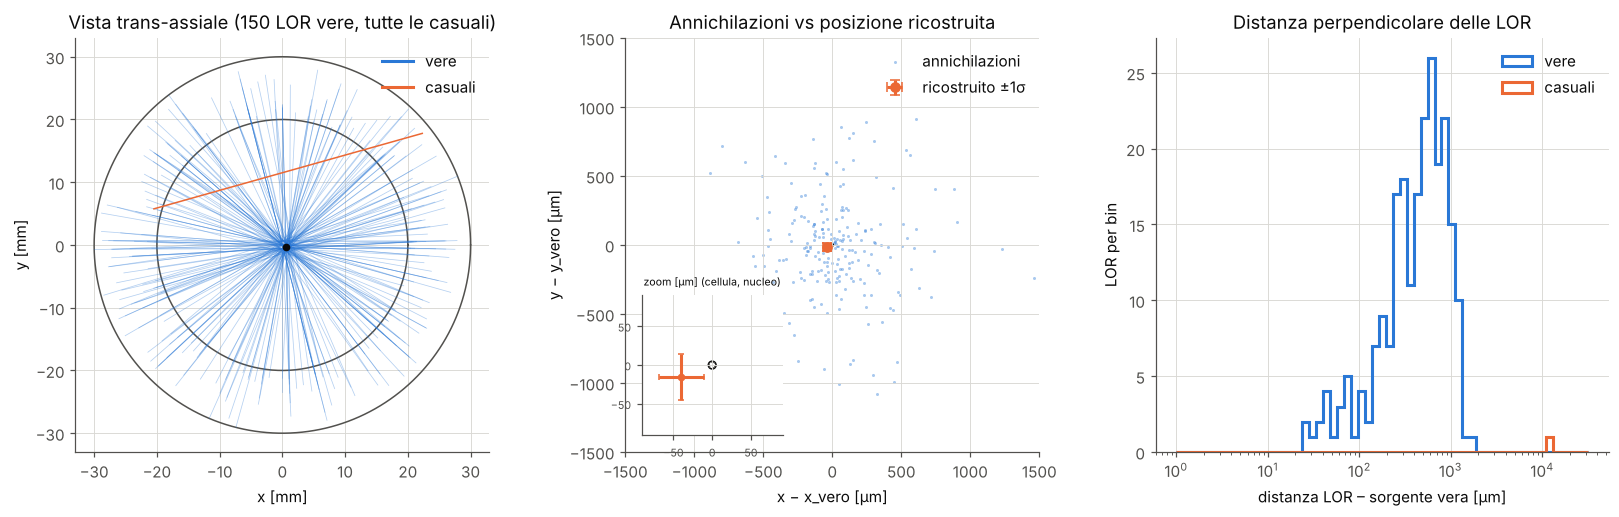

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
A, B, R = acq["A"], acq["B"], acq["rand"]
th = np.linspace(0, 2*np.pi, 400)
idx = rng.choice(np.where(~R)[0], min(150, (~R).sum()), replace=False)
for rr in (P.R_in, R_out):
    ax[0].plot(rr*np.cos(th), rr*np.sin(th), color=INK2, lw=1)
for i in idx:
    ax[0].plot([A[i,0], B[i,0]], [A[i,1], B[i,1]], color=C1, lw=0.5, alpha=0.35)
for i in np.where(R)[0]:
    ax[0].plot([A[i,0], B[i,0]], [A[i,1], B[i,1]], color=C2, lw=1.0)
ax[0].plot(*truth[:2], "o", color=INK, ms=4)
ax[0].set_aspect("equal"); ax[0].set_title("Vista trans-assiale (150 LOR vere, tutte le casuali)")
ax[0].set_xlabel("x [mm]"); ax[0].set_ylabel("y [mm]")
ax[0].plot([], [], color=C1, label="vere"); ax[0].plot([], [], color=C2, label="casuali"); ax[0].legend(loc="upper right")

an = (acq["ann"] - truth) * 1e3
ax[1].scatter(an[:,0], an[:,1], s=4, color=C1, alpha=0.4, lw=0, label="annichilazioni")
ax[1].add_patch(plt.Circle((0, 0), 5, fill=False, color=INK, lw=1.5))
e = (p_hat - truth) * 1e3
ax[1].errorbar(e[0], e[1], xerr=sig[0], yerr=sig[1], fmt="o", color=C2, ms=6, capsize=3, label="ricostruito ±1σ")
ax[1].set_aspect("equal"); ax[1].set_xlim(-1500, 1500); ax[1].set_ylim(-1500, 1500)
ax[1].set_xlabel("x − x_vero [µm]"); ax[1].set_ylabel("y − y_vero [µm]")
ax[1].set_title("Annichilazioni vs posizione ricostruita"); ax[1].legend(loc="upper right")
ins = ax[1].inset_axes([0.04, 0.04, 0.34, 0.34])
ins.add_patch(plt.Circle((0, 0), 5, fill=False, color=INK, lw=1)); ins.add_patch(plt.Circle((0, 0), 4, fill=False, color=INK2, lw=0.8, ls="--"))
ins.errorbar(e[0], e[1], xerr=sig[0], yerr=sig[1], fmt="o", color=C2, ms=4, capsize=2)
L = max(30, 1.3*(np.abs(e[:2]).max() + sig[:2].max()))
ins.set_xlim(-L, L); ins.set_ylim(-L, L); ins.set_aspect("equal"); ins.tick_params(labelsize=7); ins.set_title("zoom [µm] (cellula, nucleo)", fontsize=7)

d = perp_dist(A, B, truth) * 1e3
bins = np.logspace(0, 4.5, 60)
ax[2].hist(d[~R], bins=bins, histtype="step", color=C1, lw=2, label="vere")
ax[2].hist(d[R], bins=bins, histtype="step", color=C2, lw=2, label="casuali")
ax[2].set_xscale("log"); ax[2].set_xlabel("distanza LOR – sorgente vera [µm]"); ax[2].set_ylabel("LOR per bin")
ax[2].set_title("Distanza perpendicolare delle LOR"); ax[2].legend()
plt.tight_layout(); plt.show()

## 7. Bias sistematico da gradiente di sensibilità e sua correzione

L'accettanza geometrica di una LOR dipende solo dalla retta, e la sensibilità S(x) cala allontanandosi dal centro dello scanner, soprattutto in direzione assiale. Le annichilazioni che cadono nella zona più sensibile vengono quindi sovra-rappresentate, e il centroide ricostruito si sposta di circa

$$\mathbf b \approx s^2\,\nabla \ln S(\mathbf p),\qquad s^2 = 2\theta^2 \approx 0.14\ \text{mm}^2 ,$$

cioè di ~10 µm per una sorgente a 0.8 mm dal piano centrale. Dato che il modello diretto è noto, la correzione si ottiene con un MC autoconsistente: si simula la sorgente nella posizione stimata p̂, si misura b(p̂) = p̂_sim − p̂ e si corregge p̂ − b(p̂). Su qualche decina di µm la variazione di b è trascurabile, quindi basta un'iterazione.

In [9]:
def acceptance_bias(pos, p, rng, n_lor=300_000):
    pc = replace(p, cell_pos=tuple(pos), use_randoms=False)
    A, B, _ = simulate_lors(n_lor, pc, rng)
    ph, cov, _ = reconstruct(A, B)
    return ph - np.asarray(pos), np.sqrt(np.diag(cov))

b_hat, b_err = acceptance_bias(p_hat, P, rng)
p_corr = p_hat - b_hat
print(f"Bias stimato in p_hat   [um]: {np.round(b_hat*1e3, 1)}  (+- {np.round(b_err*1e3, 1)} MC)")
print(f"Errore prima            [um]: {np.round((p_hat-truth)*1e3, 1)}   |e| = {np.linalg.norm(p_hat-truth)*1e3:.1f}")
print(f"Errore dopo correzione  [um]: {np.round((p_corr-truth)*1e3, 1)}   |e| = {np.linalg.norm(p_corr-truth)*1e3:.1f}")
print("(con N ~ 230 l'errore e' dominato dalla statistica; il bias conta ad alta statistica, vedi sotto)")

Bias stimato in p_hat   [um]: [ 0.8 -1.6 -7.7]  (+- [0.8 0.8 0.6] MC)
Errore prima            [um]: [-40.2 -14.8 -21.2]   |e| = 47.8
Errore dopo correzione  [um]: [-41.  -13.1 -13.5]   |e| = 45.2
(con N ~ 230 l'errore e' dominato dalla statistica; il bias conta ad alta statistica, vedi sotto)


## 8. Errore di localizzazione in funzione del numero di coincidenze

Gli eventi sono i.i.d., quindi si genera una riserva grande di LOR (5·10⁵, vere più casuali nel rapporto dei rate) e la si sottocampiona. L'errore **statistico** si misura rispetto alla ricostruzione della riserva intera p_∞. Il **bias** è b = p_∞ − p_vero. La curva "senza correzione" è √(σ² + |b|²).

Il limite di confronto è σ_3D = s·√(3/(2N))·√3, che vale per il solo range e⁺ e per LOR isotrope.

In [10]:
def make_pool(p, rng, n_target=500_000):
    A, B, s = simulate_lors(n_target, p, rng)
    R = np.zeros(len(A), bool)
    if p.use_randoms:
        nr = rng.poisson(n_target * randoms_rate(p) / (p.A_Bq * p.BR_beta_plus * s))
        Ar, Br = simulate_randoms(nr, p, rng)
        A, B, R = np.r_[A, Ar], np.r_[B, Br], np.r_[R, np.ones(nr, bool)]
    p_inf, _, _ = reconstruct(A, B)
    return dict(A=A, B=B, R=R, p_inf=p_inf, bias=p_inf - np.array(p.cell_pos))

def stat_error(pool, N, reps, rng):
    A, B = pool["A"], pool["B"]; out = []
    for _ in range(reps):
        i = rng.choice(len(A), N, replace=False)
        out.append(reconstruct(A[i], B[i])[0] - pool["p_inf"])
    e = np.array(out) * 1e3
    return np.sqrt(np.mean(np.sum(e**2, axis=1))), np.sqrt(np.mean(e**2, axis=0))

pool = make_pool(P, rng)
bias_um = pool["bias"] * 1e3
print(f"Riserva: {len(pool['A'])} LOR ({pool['R'].sum()} casuali).  Bias asintotico [um]: {np.round(bias_um,1)}  |b| = {np.linalg.norm(bias_um):.1f}")

Ns = np.array([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000])
res = [stat_error(pool, N, 200 if N <= 2000 else 100, rng) for N in Ns]
rms3d = np.array([r[0] for r in res]); rms_ax = np.array([r[1] for r in res])
tot3d = np.sqrt(rms3d**2 + np.sum(bias_um**2))

s_axis = np.sqrt(2) * P.range_theta * 1e3
theory = np.sqrt(3) * s_axis * np.sqrt(3 / (2 * Ns))
kappa = np.exp(np.mean(np.log(rms3d * np.sqrt(Ns))[Ns >= 100]))      # sigma_3D = kappa / sqrt(N)
print(f"kappa = sigma_3D*sqrt(N): {kappa:.0f} um   (limite solo range e+, LOR isotrope: {np.sqrt(3)*s_axis*np.sqrt(1.5):.0f} um)")
for N, r3, ra, t3 in zip(Ns, rms3d, rms_ax, tot3d):
    print(f"N = {N:6d}:  sigma_stat 3D = {r3:6.1f} um  (x,y,z) = {np.round(ra,1)}   senza correzione bias: {t3:6.1f} um")

Riserva: 503774 LOR (3774 casuali).  Bias asintotico [um]: [-0.5 -0.6 -9.5]  |b| = 9.5


kappa = sigma_3D*sqrt(N): 944 um   (limite solo range e+, LOR isotrope: 804 um)
N =     20:  sigma_stat 3D =  210.0 um  (x,y,z) = [136.3 124.7  99.8]   senza correzione bias:  210.2 um
N =     50:  sigma_stat 3D =  138.0 um  (x,y,z) = [85.2 87.7 63.9]   senza correzione bias:  138.3 um
N =    100:  sigma_stat 3D =   96.9 um  (x,y,z) = [59.1 64.  42.4]   senza correzione bias:   97.3 um
N =    200:  sigma_stat 3D =   68.4 um  (x,y,z) = [43.6 43.5 29.8]   senza correzione bias:   69.1 um
N =    500:  sigma_stat 3D =   41.7 um  (x,y,z) = [24.7 26.9 20.1]   senza correzione bias:   42.8 um
N =   1000:  sigma_stat 3D =   29.9 um  (x,y,z) = [17.5 19.2 14.8]   senza correzione bias:   31.4 um
N =   2000:  sigma_stat 3D =   21.0 um  (x,y,z) = [12.  13.4 10.9]   senza correzione bias:   23.1 um
N =   5000:  sigma_stat 3D =   13.1 um  (x,y,z) = [8.2 8.2 6.1]   senza correzione bias:   16.2 um
N =  10000:  sigma_stat 3D =    9.3 um  (x,y,z) = [5.7 6.1 3.9]   senza correzione bias:   13.3 um


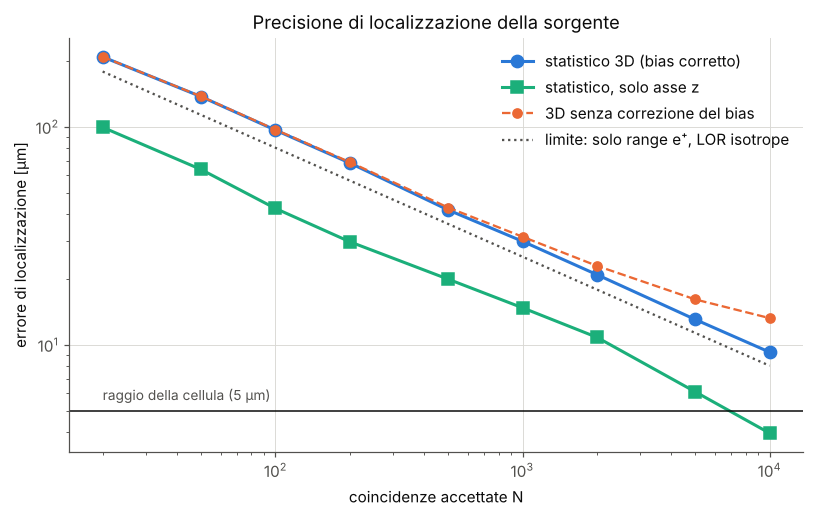

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.loglog(Ns, rms3d, "o-", color=C1, ms=8, label="statistico 3D (bias corretto)")
ax.loglog(Ns, rms_ax[:, 2], "s-", color=C3, ms=8, label="statistico, solo asse z")
ax.loglog(Ns, tot3d, "o--", color=C2, ms=6, lw=1.5, label="3D senza correzione del bias")
ax.loglog(Ns, theory, ":", color=INK2, lw=1.5, label="limite: solo range e⁺, LOR isotrope")
ax.axhline(5, color=INK, lw=1); ax.text(Ns[0], 5*1.12, "raggio della cellula (5 µm)", color=INK2, fontsize=9)
ax.set_xlabel("coincidenze accettate N"); ax.set_ylabel("errore di localizzazione [µm]")
ax.set_title("Precisione di localizzazione della sorgente"); ax.legend()
plt.tight_layout(); plt.show()

## 9. Budget degli errori

Si accende un solo contributo alla volta (il rivelatore "ideale" restituisce il punto d'interazione esatto) e si confronta con il caso completo. Si valuta l'errore statistico a N = 1000, mentre il bias asintotico è riportato a parte.

solo range e⁺                  sigma_stat =  21.5 um   |bias| =   4.2 um
solo acollinearità             sigma_stat =   3.3 um   |bias| =   0.4 um
solo rivelatore (pitch + DOI)  sigma_stat =  16.6 um   |bias| =   1.3 um
tutto tranne casuali           sigma_stat =  29.5 um   |bias| =   8.4 um
completo                       sigma_stat =  28.0 um   |bias| =   9.9 um
somma in quadratura (1-3)      sigma_stat =  27.4 um


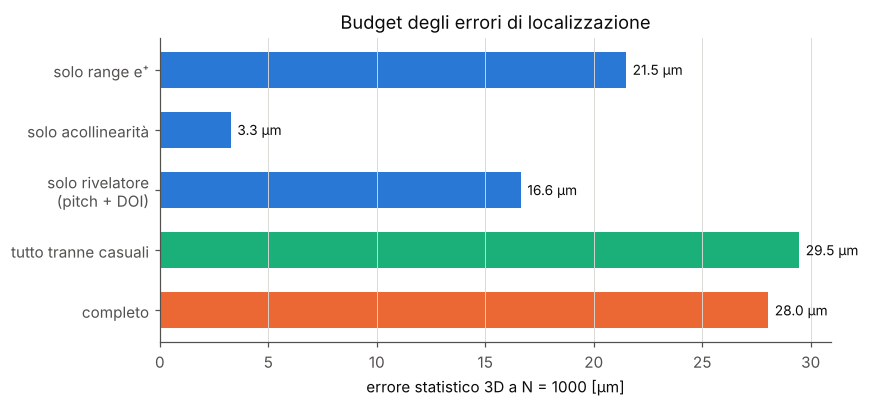

In [12]:
N_b = 1000
cases = {
    "solo range e⁺": replace(P, use_acol=False, use_detector=False, use_randoms=False),
    "solo acollinearità": replace(P, use_range=False, use_detector=False, use_randoms=False),
    "solo rivelatore\n(pitch + DOI)": replace(P, use_range=False, use_acol=False, use_randoms=False),
    "tutto tranne casuali": replace(P, use_randoms=False),
    "completo": P,
}
budget, biases = {}, {}
for name, pc in cases.items():
    pl = make_pool(pc, rng, 150_000)
    budget[name] = stat_error(pl, N_b, 150, rng)[0]
    biases[name] = np.linalg.norm(pl["bias"]) * 1e3
quad = np.sqrt(sum(budget[k]**2 for k in list(budget)[:3]))
for k in budget: print(f"{k.replace(chr(10),' '):<30} sigma_stat = {budget[k]:5.1f} um   |bias| = {biases[k]:5.1f} um")
print(f"{'somma in quadratura (1-3)':<30} sigma_stat = {quad:5.1f} um")

fig, ax = plt.subplots(figsize=(8, 3.8))
names = list(budget); vals = [budget[k] for k in names]
cols = [C1, C1, C1, C3, C2]
ax.barh(names[::-1], vals[::-1], color=cols[::-1], height=0.6)
for y, v in enumerate(vals[::-1]): ax.text(v + 0.3, y, f"{v:.1f} µm", va="center", color=INK, fontsize=9)
ax.set_xlabel(f"errore statistico 3D a N = {N_b} [µm]"); ax.set_title("Budget degli errori di localizzazione")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

## 10. Curva di progetto: tempo di acquisizione e attività per cellula

Il numero di coincidenze integra il decadimento fisico, N(T) = r_true·(1 − e^(−λT))/λ, e satura a r_true/λ. Esiste quindi una **precisione minima** σ_min = κ·√(λ/r_true) che non si supera aumentando il tempo, ma solo aumentando l'attività per cellula (o la sensibilità).

   5 Bq:    2.4 coinc/min | 50 um in   157.3 min | 20 um in  1968.6 min | 10 um in     inf min | sigma_min =  18.3 um
  20 Bq:    9.7 coinc/min | 50 um in    37.3 min | 20 um in   256.8 min | 10 um in  1968.6 min | sigma_min =   9.1 um
  50 Bq:   24.3 coinc/min | 50 um in    14.8 min | 20 um in    95.6 min | 10 um in   445.6 min | sigma_min =   5.8 um
 200 Bq:   97.3 coinc/min | 50 um in     3.7 min | 20 um in    23.1 min | 10 um in    95.6 min | sigma_min =   2.9 um


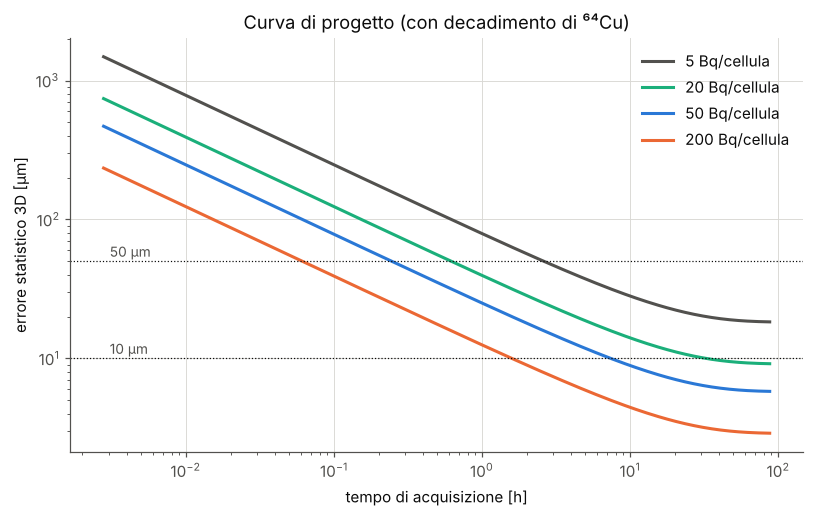

In [13]:
lam = np.log(2) / P.T_half_s
T = np.logspace(1, 5.5, 300)                     # s
acts = [5, 20, 50, 200]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for a, c in zip(acts, [INK2, C3, C1, C2]):
    rt = a * P.BR_beta_plus * sens
    N_T = rt * (1 - np.exp(-lam*T)) / lam
    ax.loglog(T/3600, kappa / np.sqrt(N_T), color=c, label=f"{a} Bq/cellula")
    smin = kappa * np.sqrt(lam / rt)
    t = lambda sig: (-np.log(1 - (kappa/sig)**2 * lam / rt) / lam / 60) if (kappa/sig)**2*lam/rt < 1 else np.inf
    print(f"{a:4d} Bq: {rt*60:6.1f} coinc/min | 50 um in {t(50):7.1f} min | 20 um in {t(20):7.1f} min | 10 um in {t(10):7.1f} min | sigma_min = {smin:5.1f} um")
for y in (10, 50): ax.axhline(y, color=INK, lw=0.8, ls=":"); ax.text(T[0]/3600*1.1, y*1.08, f"{y} µm", color=INK2, fontsize=9)
ax.set_xlabel("tempo di acquisizione [h]"); ax.set_ylabel("errore statistico 3D [µm]")
ax.set_title("Curva di progetto (con decadimento di ⁶⁴Cu)"); ax.legend(); plt.tight_layout(); plt.show()

## 11. Conclusioni e limiti del modello

- **Il singolo decadimento non si ricostruisce alla scala della cellula.** Ogni LOR passa in media a ~centinaia di µm dal punto di decadimento, a causa del range dell'e⁺ e della risoluzione del rivelatore, e la TOF (σ ≈ 13 mm) non aiuta. Quello che si ricostruisce con precisione di decine di µm è la **posizione della sorgente** (il nucleo), come parametro comune a N eventi, con σ ∝ 1/√N.
- Nel budget a N fissato dominano il **range del positrone** e il **rivelatore** (pitch 1 mm + DOI), che sono dello stesso ordine; l'acollinearità è trascurabile su un anello di 4 cm di diametro. I casuali da ¹⁷⁶Lu sono < 1% e lo stimatore robusto li elimina.
- **Anisotropia.** Con un'estensione assiale limitata le LOR accettate sono quasi trans-assiali. Ciascuna vincola quindi pienamente z e solo una combinazione di (x, y): M ≈ N·diag(½, ½, 1), per cui la precisione **assiale è migliore** di quella trans-assiale.
- **Bias.** Il gradiente di sensibilità sposta il centroide di ~10 µm per una sorgente fuori dal piano centrale. Diventa dominante sopra N ~ 5000 e va corretto con il MC autoconsistente della sezione 7, oppure con una mappa di sensibilità misurata.
- **Limite fisico.** Con il decadimento di ⁶⁴Cu (T½ = 12.7 h) la statistica totale è finita: a 50 Bq per cellula la precisione statistica satura attorno a ~6 µm. Per la scala sub-cellulare servono attività maggiori o un rivelatore più sensibile (anello più lungo, cristalli più spessi).
- **Limiti del modello:** non sono simulati lo scattering Compton nel mezzo e nel rivelatore (inter-crystal scatter), l'annichilazione in volo, il tempo morto esplicito e la distribuzione dell'energia depositata; la frazione in finestra è un parametro efficace. Il range presuppone acqua omogenea: una cellula adesa al fondo di un pozzetto in plastica con aria sopra ha un range asimmetrico, e quindi un **bias aggiuntivo** del centroide che si può stimare solo simulando la geometria reale in Geant4.
- **Validazione consigliata:** sostituire il modello Γ con i vettori Geant4-DNA (sezione 2) e confrontare con una simulazione GATE/Geant4 completa dello scanner.